## Presentado por:
## Esteban Garcia otalvaro
## Fabian Andres Posso Garcia

##Practica 1-Introducción a Python y a los sistemas discretos

In [57]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd

##Repaso de Numpy

In [58]:

# Se crea un par de vectores a y b
a = np.array([3.1, 1, -0.5, -3.2, 6])
b = np.array([1, 3, 2.2, 5.1, 1])

In [59]:
# Se realiza la multiplicación escalar de a y b con el método  
# dot().
c = a.dot(b)
print("a•b =", c)

a•b = -5.32


In [60]:
# Se implementa la multiplicación punto a punto de a y b.
c = a*b
print("a*b =", c)


a*b = [  3.1    3.    -1.1  -16.32   6.  ]


In [61]:
# Se crea una matriz A 3x3.
A = np.array([[2, -1, -3], [4, 1.5, -2.5], [7.3, -0.9, 0.2]])


In [62]:
# Se obtiene la matriz transpuesta de A.
AT = np.transpose(A)
print("A^T =\n", AT)

A^T =
 [[ 2.   4.   7.3]
 [-1.   1.5 -0.9]
 [-3.  -2.5  0.2]]


In [63]:
# Ejemplificando las funciones ones, round, ceil y floor.
#  - ones: Crea una matriz o vector de unos, 
#          enteros o flotantes.
unit_matrix = np.ones((3, 3), int)
print("Matriz de unos:\n", unit_matrix)

#  - round: Redondea los elementos de una matriz o vector a 
#           cierta cantidad de decimales.
example_matrix = np.array([[1.234, 2.345, 3.456], 
                           [4.567, 5.678, 6.789]])
rounded_matrix = np.round(example_matrix, 2)
print("Matriz redondeada a 2 decimales:\n", rounded_matrix)

# - ceil: Redondea los elementos de una matriz o vector al
#         entero superior más cercano.
ceiled_matrix = np.ceil(example_matrix)
print("Matriz redondeada al entero superior más cercano:\n", 
      ceiled_matrix)

# - floor: Redondea los elementos de una matriz o vector al
#          entero inferior más cercano.
floored_matrix = np.floor(example_matrix)
print("Matriz redondeada al entero inferior más cercano:\n", 
      floored_matrix)

Matriz de unos:
 [[1 1 1]
 [1 1 1]
 [1 1 1]]
Matriz redondeada a 2 decimales:
 [[1.23 2.35 3.46]
 [4.57 5.68 6.79]]
Matriz redondeada al entero superior más cercano:
 [[2. 3. 4.]
 [5. 6. 7.]]
Matriz redondeada al entero inferior más cercano:
 [[1. 2. 3.]
 [4. 5. 6.]]


In [64]:
# Accediendo al valor de la primera fila, tercera columna de 
# la matriz A e imprimiendolo.
value = A[0, 2]
print("Valor de la primera fila, tercera columna de A:", 
      value)

Valor de la primera fila, tercera columna de A: -3.0


In [65]:
# Imprimiendo la segunda fila de la matriz A.
row = A[1]
print("Segunda fila de A:", row)

Segunda fila de A: [ 4.   1.5 -2.5]


In [66]:
# Imprimiendo las dimensiones de la matriz A.
dimensions = A.shape
print(f"Dimensiones de A: \n {dimensions[0]} filas y \
{dimensions[1]} columnas")

Dimensiones de A: 
 3 filas y 3 columnas


In [67]:
# Construyendo la función y[n] = sin(π * 0.12n) con n 
# entre 0 y 100.
def y_1(n):
    return np.sin(np.pi * 0.12 * n)

n_range = np.arange(0, 101)
y_1_values = y_1(n_range)

In [68]:
# Construyendo la función y2[n] = cos(2π * 0.03n)
def y_2(n):
    return np.cos(2 * np.pi * 0.03 * n)

y_2_values = y_2(n_range)

In [69]:
# Generando una tercera señal que es suma de las dos 
# anteriores:
# s[n] = y[n] + y2[n]
# y otra que es su producto:
# t[n] = y[n] * y2[n]

s_values = y_1_values + y_2_values
t_values = y_1_values * y_2_values

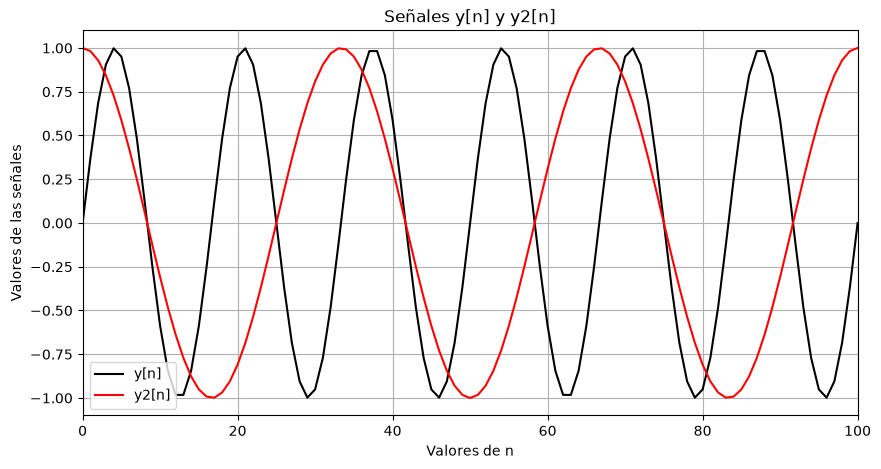

In [70]:
# Graficando en la misma figura las señales y[n] y y2[n]
def graph(n, signal1, signal2, name1, name2):
    plt.figure(figsize=(10,5))
    plt.plot(n, signal1, label=name1, color='black')
    plt.plot(n, signal2, label=name2, color='red')
    plt.xlabel('Valores de n')
    plt.xlim(np.min(n), np.max(n))
    plt.ylabel('Valores de las señales')
    plt.title(f'Señales {name1} y {name2}')
    plt.legend()
    plt.grid()
    plt.show()

graph(n_range, y_1_values, y_2_values, 'y[n]', 'y2[n]')

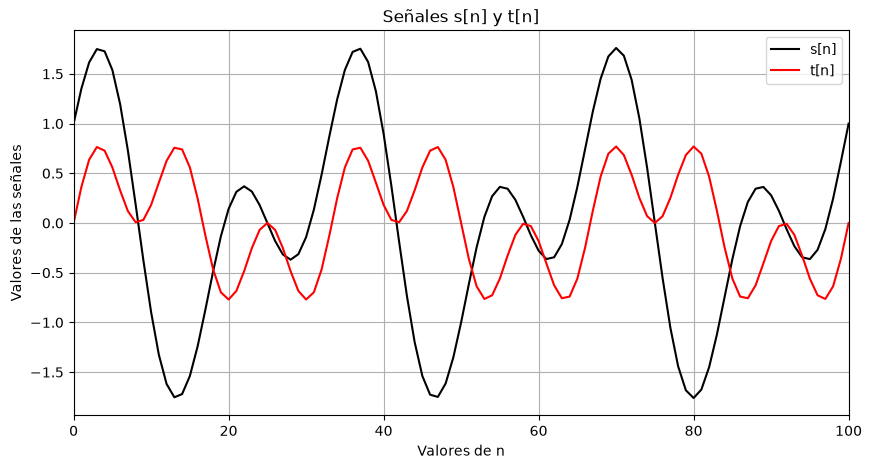

In [71]:
# # Graficando en la misma figura las señales s[n] y t[n]
graph(n_range, s_values, t_values, 's[n]', 't[n]')


Diagrama del flujo de trabajo colaborativo en Git/GitHub
---------------------------------------------------------
Basado en el procedimiento del curso: clonar, editar, registrar
cambios y enviarlos al repositorio remoto, trayendo antes los
últimos cambios con pull para evitar conflictos.

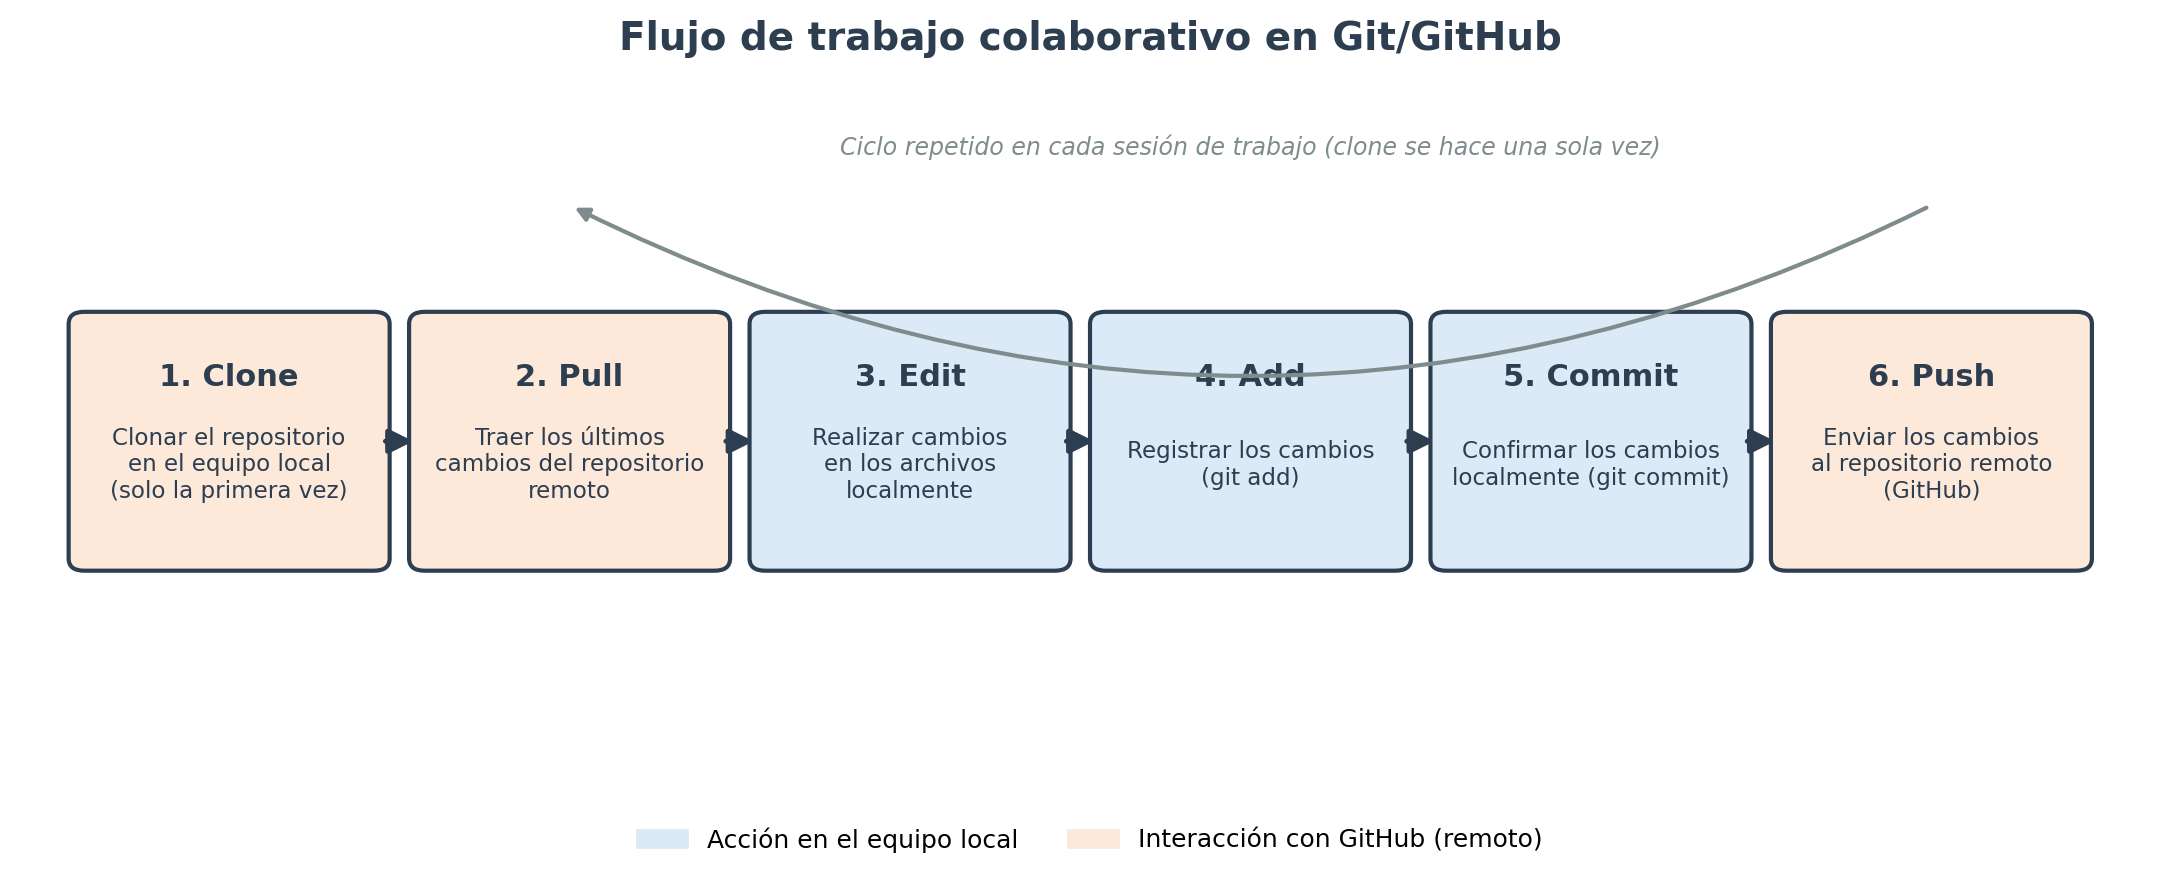

##Representación de Señales Discretas

## Secuencias discretas elementales

### Impulso unitario (dado en el enunciado)

$$\delta(n-n_0)=\begin{cases}1 & n=n_0\\ 0 & n\neq n_0\end{cases}$$

In [72]:

#Impulso unitario
def impseq(n0, n1, n2):
    # Genera x(n) = delta(n-n0); n1 <= n <= n2
    # --------------------------------------------
    n = np.arange(n1, n2+1)   # Se crea el vector de muestras
    x = (n - n0) == 0
    return [x, n]



### p) Escalón unitario

$$u(n-n_0)=\begin{cases}1 & n\geq n_0\\ 0 & n<n_0\end{cases}$$

Se implementa con la misma lógica que `impseq`, cambiando la condición `==` por `>=`.

In [73]:
#Escalon unitario
def stepseq(n0, n1, n2):
    # Genera x(n) = u(n-n0); n1 <= n <= n2
    # --------------------------------------------
    n = np.arange(n1, n2+1)
    x = (n - n0) >= 0
    return [x, n]

### q) Rampa

$$r(n-n_0)=\begin{cases}0 & n<n_0\\ n-n_0 & n\geq n_0\end{cases}$$

Se generaliza para admitir una pendiente `m` (por defecto 1).

In [74]:
#Rampa Unitaria

def rampseq(n0, n1, n2, m=1.0):
    # Genera x(n) = m*r(n-n0); n1 <= n <= n2
    # --------------------------------------------
    n = np.arange(n1, n2+1)
    x = np.where(n - n0 >= 0, m * (n - n0), 0.0)
    return [x, n]


### Verificación gráfica de las tres funciones elementales

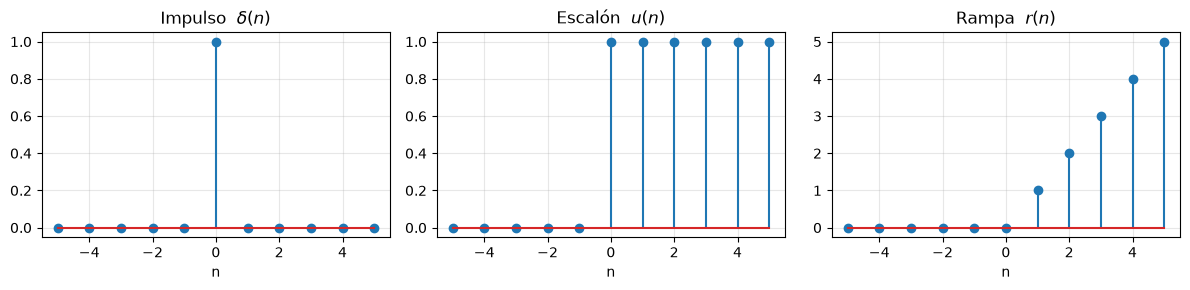

In [75]:
d, nd = impseq(0, -5, 5)
u, nu = stepseq(0, -5, 5)
r, nr = rampseq(0, -5, 5)

fig, axs = plt.subplots(1, 3, figsize=(12, 3))
axs[0].stem(nd, d); axs[0].set_title('Impulso  $\\delta(n)$'); axs[0].set_xlabel('n')
axs[1].stem(nu, u); axs[1].set_title('Escalón  $u(n)$');       axs[1].set_xlabel('n')
axs[2].stem(nr, r); axs[2].set_title('Rampa  $r(n)$');         axs[2].set_xlabel('n')
for ax in axs:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## r) Generación de secuencias compuestas

### a) $x_1(n) = 3\delta(n+1) + 5\delta(n+3) + 3\delta(n+2) + 3\delta(n) + \delta(n)$

Como el término más adelantado es $\delta(n+3)=\delta(n-(-3))$, el vector de muestras debe cubrir **al menos** $-3 \leq n \leq 0$; se usa un rango un poco más amplio para visualizar mejor la señal.

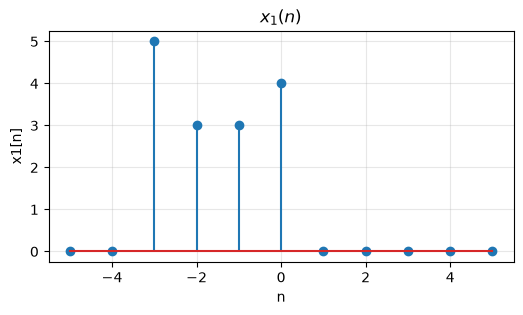

In [76]:
n1, n2 = -5, 5
d1, n = impseq(-1, n1, n2)
d2, _ = impseq(-3, n1, n2)
d3, _ = impseq(-2, n1, n2)
d4, _ = impseq(0, n1, n2)
d5, _ = impseq(0, n1, n2)

x1 = 3*d1 + 5*d2 + 3*d3 + 3*d4 + d5

plt.figure(figsize=(6, 3))
plt.stem(n, x1)
plt.title('$x_1(n)$')
plt.xlabel('n'); plt.ylabel('x1[n]'); plt.grid(True, alpha=0.3)
plt.show()

### b) Sistema con adelantos (imagen del enunciado)

El diagrama multiplica $u(n)$ por $-2$ y lo adelanta 4 muestras, multiplica $u(n)$ por $3$ y lo adelanta 2 muestras, y suma ambas ramas:

$$x_2(n) = -2\,u(n+4) + 3\,u(n+2), \qquad -6 \leq n \leq 6$$

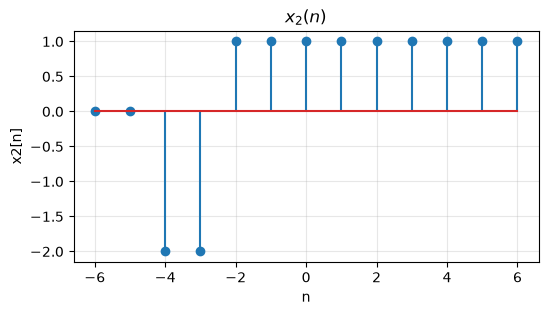

In [77]:
n1, n2 = -6, 6
u1, n = stepseq(-4, n1, n2)
u2, _ = stepseq(-2, n1, n2)

x2 = -2*u1 + 3*u2

plt.figure(figsize=(6, 3))
plt.stem(n, x2)
plt.title('$x_2(n)$')
plt.xlabel('n'); plt.ylabel('x2[n]'); plt.grid(True, alpha=0.3)
plt.show()


### c) Sistema con multiplicador (imagen del enunciado)

$$x_3(n) = e^{0.01n}\cdot \sin(2\pi n), \qquad 0 \leq n \leq 100$$

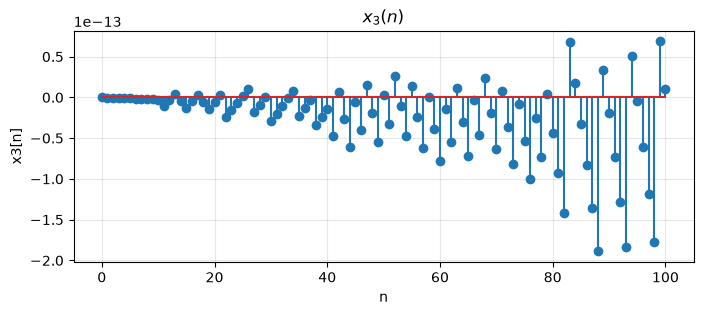

In [78]:
n = np.arange(0, 101)
x3 = np.exp(0.01*n) * np.sin(2*np.pi*n)

plt.figure(figsize=(8, 3))
plt.stem(n, x3)
plt.title('$x_3(n)$')
plt.xlabel('n'); plt.ylabel('x3[n]'); plt.grid(True, alpha=0.3)
plt.show()


### d) $x_4(n) = 2r(n+3) - r(n-2) - 5u(n-3), \ -10 \leq n \leq 10$

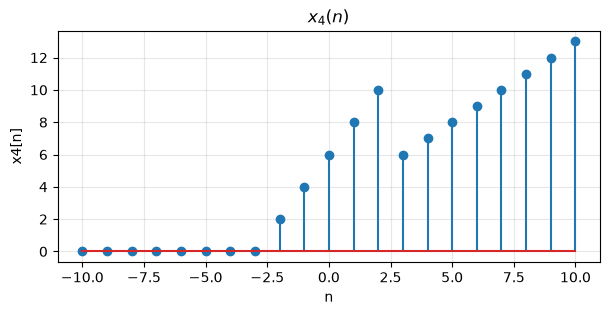

In [79]:
n1, n2 = -10, 10
r1, n = rampseq(-3, n1, n2)
r2, _ = rampseq(2, n1, n2)
u1, _ = stepseq(3, n1, n2)

x4 = 2*r1 - r2 - 5*u1

plt.figure(figsize=(7, 3))
plt.stem(n, x4)
plt.title('$x_4(n)$')
plt.xlabel('n'); plt.ylabel('x4[n]'); plt.grid(True, alpha=0.3)
plt.show()

## s) Secuencia por tramos y su derivada

$$x[n] = \begin{cases} r[n] & 0\leq n \leq 5\\ r[n-5] & 6 \leq n \leq 11\\ r[n-10] & 12 \leq n \leq 17 \end{cases}$$

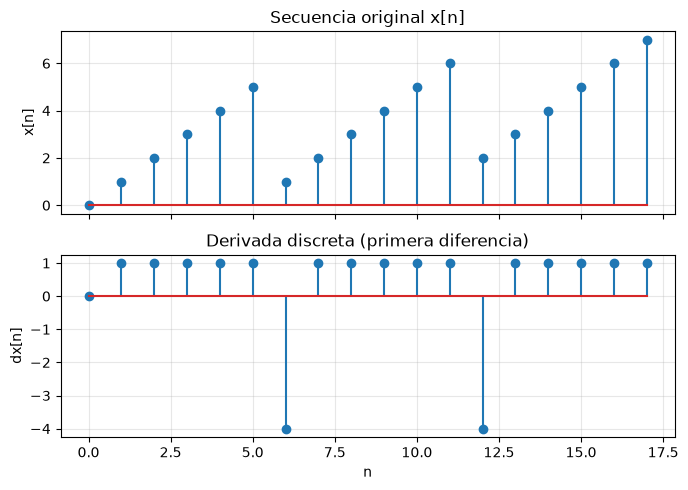

In [81]:
n = np.arange(0, 18)
x = np.zeros_like(n, dtype=float)

seg1 = (n >= 0)  & (n <= 5)
seg2 = (n >= 6)  & (n <= 11)
seg3 = (n >= 12) & (n <= 17)

x[seg1] = n[seg1] - 0
x[seg2] = n[seg2] - 5
x[seg3] = n[seg3] - 10

# Derivada discreta (primera diferencia): dx[n] = x[n] - x[n-1]
dx = np.diff(x, prepend=x[0])

fig, axs = plt.subplots(2, 1, figsize=(7, 5), sharex=True)
axs[0].stem(n, x)
axs[0].set_title('Secuencia original x[n]')
axs[0].set_ylabel('x[n]'); axs[0].grid(True, alpha=0.3)

axs[1].stem(n, dx)
axs[1].set_title('Derivada discreta (primera diferencia)')
axs[1].set_xlabel('n'); axs[1].set_ylabel('dx[n]'); axs[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()




**Explicación:** dentro de cada tramo la pendiente es constante (1), por lo que la derivada vale 1 casi en todas partes. Sin embargo, en los puntos donde la señal original salta de un tramo a otro ($n=6$ y $n=12$) hay una discontinuidad grande y negativa en la derivada, algo que no ocurriría en una rampa continua sin quiebres. Esto pasa porque la "derivada" discreta es en realidad una diferencia finita: no mide una pendiente instantánea, sino el salto entre dos muestras consecutivas, así que reacciona de forma exagerada ante los saltos abruptos que introduce la definición por tramos.

## t) Secuencia por concatenación de funciones elementales

$$x(n) = \{0,1,2,3,4,\hat5,4,3,2,1,0,1,2,3,4,5,5,5,5,10,10,10,10\}, \quad -5\leq n \leq 17$$

Analizando la señal por tramos se identifica: una rampa ascendente ($-5\leq n\leq0$), un pulso triangular descendente ($0\leq n\leq5$), otra rampa ascendente ($5\leq n\leq10$), una meseta en 5 ($10\leq n\leq13$) y un salto final a 10 ($n\geq14$). Esto se logra combinando rampas y un escalón:

$$x(n) = r(n+5) - 2r(n) + 2r(n-5) - r(n-10) + 5u(n-14)$$

¿Coincide con la secuencia del enunciado? True


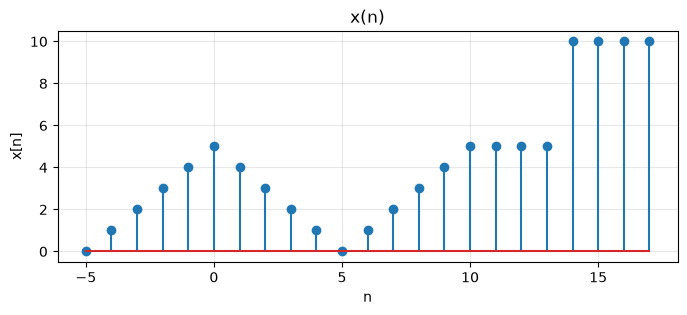

In [83]:
def senal_t(n, shift=0):
    """Evalúa x(n - shift) usando la combinación de rampas y escalón."""
    m = np.asarray(n) - shift
    r1 = np.where(m - (-5) >= 0, (m - (-5)), 0.0)
    r2 = np.where(m - 0   >= 0, (m - 0),    0.0)
    r3 = np.where(m - 5   >= 0, (m - 5),    0.0)
    r4 = np.where(m - 10  >= 0, (m - 10),   0.0)
    u1 = (m - 14 >= 0).astype(float)
    return r1 - 2*r2 + 2*r3 - r4 + 5*u1

n = np.arange(-5, 18)
x = senal_t(n)

esperado = [0,1,2,3,4,5,4,3,2,1,0,1,2,3,4,5,5,5,5,10,10,10,10]
print('¿Coincide con la secuencia del enunciado?', np.allclose(x, esperado))

plt.figure(figsize=(8, 3))
plt.stem(n, x)
plt.title('x(n)')
plt.xlabel('n'); plt.ylabel('x[n]'); plt.grid(True, alpha=0.3)
plt.show()

### a) $x_5(n) = 2x(n-4) + x(n)$
### b) $x_6(n) = 0.001\,e^{0.5n}\,x(n) + 10\sin(0.05\pi n)\,x(n+2), \ -20\leq n \leq 20$

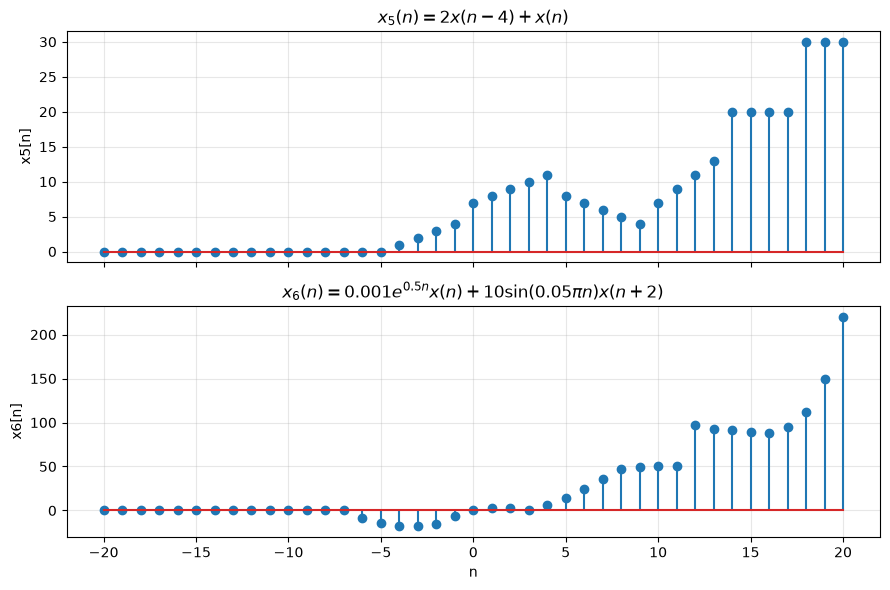

In [84]:
n = np.arange(-20, 21)

x5 = 2*senal_t(n, shift=4) + senal_t(n, shift=0)
x6 = 0.001*np.exp(0.5*n)*senal_t(n, shift=0) + 10*np.sin(0.05*np.pi*n)*senal_t(n, shift=-2)

fig, axs = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
axs[0].stem(n, x5)
axs[0].set_title('$x_5(n) = 2x(n-4) + x(n)$')
axs[0].set_ylabel('x5[n]'); axs[0].grid(True, alpha=0.3)

axs[1].stem(n, x6)
axs[1].set_title('$x_6(n) = 0.001e^{0.5n}x(n) + 10\\sin(0.05\\pi n)x(n+2)$')
axs[1].set_xlabel('n'); axs[1].set_ylabel('x6[n]'); axs[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Repaso de Pandas

In [87]:
# Se importa la librería Pandas con el pseudónimo pd.
import pandas as pd

# Función que recibe diccionario con las notas de los alumnos de 
# un curso y devuelve una seria con la nota mínima, máxima, media
# y la desbviación típica.

# Se crea diccionario con las notas de los alumnos.
notas = {
    'Alumno1': [4.5, 3.2, 4.8],
    'Alumno2': [3.8, 4.0, 4.5],
    'Alumno3': [4.0, 3.5, 4.2],
    'Alumno4': [2.5, 3.0, 3.5],
    'Alumno5': [4.2, 4.5, 4.8],
}

def notas_estadisticas(notas):
    # Se crea un DataFrame a partir del diccionario de notas.
    df = pd.DataFrame(notas)

    # Se calculan las estadísticas.
    min_nota = df.min()
    max_nota = df.max()
    mean_nota = df.mean()
    std_nota = df.std()

    # Se crea un nuevo DataFrame con las estadísticas.
    estadisticas = pd.DataFrame({
        'Mínima': min_nota,
        'Máxima': max_nota,
        'Media': mean_nota,
        'Desviación Típica': std_nota
    })

    return estadisticas

print(f"Estadísticas de las notas de los alumnos:\n{notas_estadisticas(notas)}")

Estadísticas de las notas de los alumnos:
         Mínima  Máxima     Media  Desviación Típica
Alumno1     3.2     4.8  4.166667           0.850490
Alumno2     3.8     4.5  4.100000           0.360555
Alumno3     3.5     4.2  3.900000           0.360555
Alumno4     2.5     3.5  3.000000           0.500000
Alumno5     4.2     4.8  4.500000           0.300000


In [88]:
# Se cargan los datos desde "datos.csv" en un DataFrame.
data = pd.read_csv("datos.csv", sep=";", header=0)

# Se imprime la primera y última fila del DF para conocer la 
# estructura de los datos.
print("Primeras filas del DataFrame:\n", data.head())
print("Últimas filas del DataFrame:\n", data.tail())

# Borrar la columna "Unnamed: 0" del DataFrame.
data = data.drop("Unnamed: 0", axis=1)

# Calcular el IMC con la formula IMC = peso(kg) / altura(m)^2,

# Intercambiando los datos de las columnas "Weight" y "Height".
data["Weight"], data["Height"] = data["Height"], data["Weight"]

# Conociendo que la altura se entrega en cm.
IMC = data["Weight"] / (data["Height"]/100)**2

# Agregando el IMC como nueva columna llamda "BMI".
data["BMI"] = IMC

# Categorizar los participantes según su IMC en:
#  - Bajo peso: IMC < 18.5
#  - Normal: 18.5 <= IMC < 25
#  - Sobrepeso: 25 <= IMC < 30
#  - Obesidad: IMC >= 30

def categorize_IMC(IMC):
    if IMC < 18.5:
        return "Bajo peso"
    elif IMC < 25:
        return "Normal"
    elif IMC < 30:
        return "Sobrepeso"
    else:
        return "Obesidad"

for IMC in data["BMI"]:
    data["Category"] = data["BMI"].apply(categorize_IMC)

print("DataFrame con la columna BMI y Category:\n", data)

Primeras filas del DataFrame:
    Unnamed: 0  Gender  FSIQ  VIQ  PIQ  Weight  Height  MRI_Count
0           1  Female   133  132  124   118.0    64.5     816932
1           3    Male   139  123  150   143.0    73.3    1038437
2           4    Male   133  129  128   172.0    68.8     965353
3           5  Female   137  132  134   147.0    65.0     951545
4           6  Female    99   90  110   146.0    69.0     928799
Últimas filas del DataFrame:
     Unnamed: 0  Gender  FSIQ  VIQ  PIQ  Weight  Height  MRI_Count
33          36  Female   133  129  128   153.0    66.5     948066
34          37    Male   140  150  124   144.0    70.5     949395
35          38  Female    88   86   94   139.0    64.5     893983
36          39    Male    81   90   74   148.0    74.0     930016
37          40    Male    89   91   89   179.0    75.5     935863
DataFrame con la columna BMI y Category:
     Gender  FSIQ  VIQ  PIQ  Weight  Height  MRI_Count        BMI   Category
0   Female   133  132  124    64.5 